# 2026–2027 El Niño: Pacific sovereign revenue risk

This notebook reads the exact completed event assessment and explains its climate, agricultural and fiscal channels. It does not silently refit models or download a different vintage. Run `uv run tradewinds update` to create a new assessment.

**Question:** How could annual government revenue in 2026 and 2027 differ with this event versus an explicit no-event counterfactual? This is a conditional real-revenue study, not observed losses, sovereign default probability or an identified causal tax multiplier.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if not (ROOT / 'configs/project.yaml').exists():
    ROOT = ROOT.parent
state_path = ROOT / 'artifacts/state.json'
state = json.loads(state_path.read_text()) if state_path.exists() else {}
REPORT = Path(state['report_dir']) if state.get('risk_status') == 'event_specific_conditional_assessment' else ROOT / 'reports/event'
meta = json.loads((REPORT / 'event_risk_metadata.json').read_text())
print('Assessment:', meta['climate']['as_of'])
print('Official forecast issue:', meta['climate']['forecast_issue_date'])
print('Countries:', ', '.join(meta['countries']))
print('Units:', meta['units'])

Assessment: 2026-09-07
Official forecast issue: 2026-08-13
Countries: AUS, FJI, IDN, MYS, PHL, PNG, SLB, THA, TON, VNM, VUT, WSM
Units: constant 2025 USD, GDP-deflated; fixed 2025 exchange rate


## 1. Official event forecast versus counterfactual

Observed centered RONI seasons are filtered by availability. NOAA supplies future marginal quantiles. An empirical forecast-error copula approximates their temporal dependence; forecasts for overlapping seasons are not assumed independent. After the official horizon, a labelled statistical extension completes 2027. The counterfactual removes the event from AMJ 2026 onward while retaining earlier La Niña history.

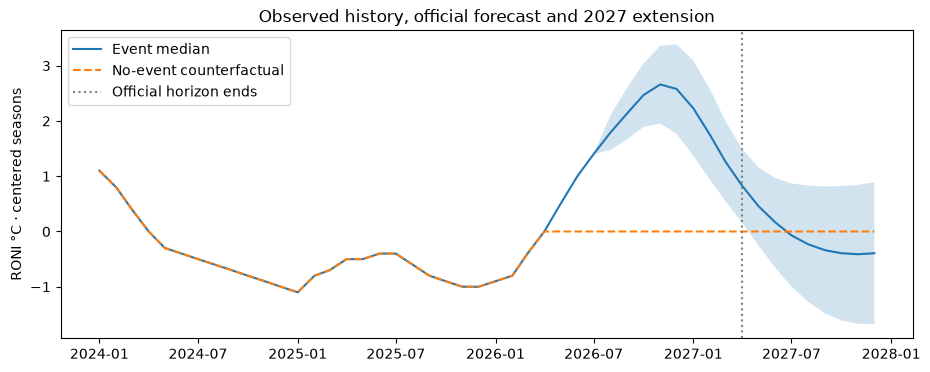

,period,source,p05,p50,p95,neutral
36,2027-01-01,CPC_marginal_with_modeled_dependence,1.369845,2.229364,3.092220,0.0
37,2027-02-01,CPC_marginal_with_modeled_dependence,0.930670,1.742566,2.564741,0.0
38,2027-03-01,CPC_marginal_with_modeled_dependence,0.551344,1.267088,2.004105,0.0
39,2027-04-01,CPC_marginal_with_modeled_dependence,0.160524,0.827097,1.494228,0.0
40,2027-05-01,model_extension,-0.248010,0.460420,1.160167,0.0
41,2027-06-01,model_extension,-0.656436,0.166949,0.970855,0.0
42,2027-07-01,model_extension,-0.996539,-0.069885,0.867723,0.0
43,2027-08-01,model_extension,-1.274583,-0.231945,0.830971,0.0
44,2027-09-01,model_extension,-1.483398,-0.339020,0.814461,0.0
45,2027-10-01,model_extension,-1.608380,-0.392920,0.823263,0.0


In [2]:
climate = pd.read_csv(REPORT / 'event_climate.csv', parse_dates=['period'])
fig, ax = plt.subplots(figsize=(11, 4))
ax.fill_between(climate.period, climate.p05, climate.p95, alpha=.2)
ax.plot(climate.period, climate.p50, label='Event median')
ax.plot(climate.period, climate.neutral, '--', label='No-event counterfactual')
ax.axvline(pd.Timestamp(meta['climate']['official_last_center_month']), color='grey', linestyle=':', label='Official horizon ends')
ax.set(ylabel='RONI °C · centered seasons', title='Observed history, official forecast and 2027 extension')
ax.legend(); plt.show()
climate.tail(12)

## 2. Estimated economic and fiscal relationships

Hierarchical country agricultural-value-added models use warm/cold ENSO exposures, two-year lags, growth persistence, economic controls and trends. The fiscal model estimates revenue-growth responses to agricultural and non-agricultural growth contributions, rather than assuming a fraction of gross farm sales becomes tax.

The coefficients are observational associations, can be negative, and may be weakly identified. Revenue includes grants. The 2027 simulation carries forward each case's 2026 sector levels and revenue changes.

In [3]:
transmission = pd.read_csv(REPORT / 'fiscal_transmission.csv')
transmission

,country,agri_revenue_elasticity_mean,agri_revenue_elasticity_p05,agri_revenue_elasticity_median,agri_revenue_elasticity_p95,p_positive,interpretation
0,AUS,0.227198,-1.235642,0.229343,1.694806,0.6047,Coefficient on agriculture-share-weighted real...
1,FJI,0.200390,-1.305196,0.218767,1.675105,0.5951,Coefficient on agriculture-share-weighted real...
2,IDN,0.249812,-1.398533,0.254061,1.909896,0.6135,Coefficient on agriculture-share-weighted real...
3,MYS,0.333490,-1.223605,0.320543,1.963399,0.6442,Coefficient on agriculture-share-weighted real...
4,PHL,0.520208,-0.974137,0.464547,2.210210,0.7019,Coefficient on agriculture-share-weighted real...
5,PNG,0.273488,-1.394158,0.289860,1.924834,0.6204,Coefficient on agriculture-share-weighted real...
6,SLB,-0.006894,-1.721833,0.054225,1.493235,0.5224,Coefficient on agriculture-share-weighted real...
7,THA,0.443104,-1.027377,0.398793,2.117149,0.6769,Coefficient on agriculture-share-weighted real...
8,TON,0.244014,-1.171804,0.249942,1.652083,0.6121,Coefficient on agriculture-share-weighted real...
9,VNM,0.434960,-1.205206,0.386205,2.275063,0.6648,Coefficient on agriculture-share-weighted real...


In [4]:
anchors = pd.read_csv(REPORT / 'event_anchors.csv')
anchors

,country,agriculture_anchor_year,revenue_anchor_year,revenue_anchor_status,bridge_years,initial_revenue_2025usd,imf_wdi_gdp_ratio
0,AUS,2025,2025,IMF estimate,0,6.746991e+11,1.085742
1,FJI,2025,2025,IMF estimate,0,1.755678e+09,1.061934
2,IDN,2025,2025,IMF estimate,0,1.919498e+11,1.110741
3,MYS,2025,2025,IMF estimate,0,9.394096e+10,1.062513
4,PHL,2025,2025,IMF estimate,0,9.884248e+10,1.025942
5,PNG,2024,2025,IMF estimate,1,5.633160e+09,1.132897
6,SLB,2024,2025,IMF estimate,1,6.368568e+08,1.111320
7,THA,2025,2025,IMF estimate,0,1.215142e+11,1.187802
8,TON,2024,2025,IMF estimate,1,3.510848e+08,1.328407
9,VNM,2025,2025,IMF estimate,0,9.854914e+10,1.128713


## 3. Actuarial outcomes

Loss = paired neutral revenue minus event revenue. Negative values are gains. VaR and expected shortfall use the positive shortfall distribution. Totals preserve cross-country simulation dependence. Constant 2025 dollars must not be subtracted from nominal IMF budget projections.

In [5]:
aggregate = pd.read_csv(REPORT / 'event_aggregate_risk.csv')
view = aggregate.copy()
for col in view:
    if '2025usd' in col:
        view[col] /= 1e9
print('Monetary columns below are billions of constant 2025 USD.')
view

Monetary columns below are billions of constant 2025 USD.


,period,scope,revenue_loss_2025usd_mean,revenue_loss_2025usd_p05,revenue_loss_2025usd_median,revenue_loss_2025usd_p95,agriculture_loss_2025usd_mean,agriculture_loss_2025usd_p05,agriculture_loss_2025usd_median,agriculture_loss_2025usd_p95,p_revenue_loss,p_loss_above_1pct_revenue,var95_2025usd,es95_2025usd
0,2026,all_modeled,0.357334,-1.202325,0.206646,2.333534,5.792131,-0.908807,5.603961,13.207135,0.6306,0.0000,2.333534,3.324366
1,2026,Pacific_islands,0.006850,-0.043143,0.003369,0.065675,0.145842,-0.051703,0.132095,0.387258,0.5902,0.0205,0.065675,0.103794
2,2026,excluding_Australia,0.312844,-0.978398,0.182025,1.963048,5.308474,-0.633669,5.138855,11.961897,0.6366,0.0000,1.963048,2.799798
3,2027,all_modeled,0.460447,-1.747761,0.254178,3.239012,7.514626,-1.984142,7.236676,17.984485,0.6175,0.0000,3.239012,4.614393
4,2027,Pacific_islands,0.007616,-0.062284,0.003495,0.089792,0.188906,-0.099202,0.170893,0.542335,0.5702,0.0415,0.089792,0.140444
5,2027,excluding_Australia,0.364635,-1.293501,0.206059,2.500348,6.418229,-1.890710,6.169889,15.625597,0.6198,0.0011,2.500348,3.552546
6,2026–2027,all_modeled,0.817781,-2.881156,0.470921,5.523944,13.306757,-2.152958,12.791203,30.866752,0.6250,0.0000,5.523944,7.767767
7,2026–2027,Pacific_islands,0.014466,-0.102876,0.007039,0.153846,0.334748,-0.135444,0.304541,0.913693,0.5812,0.0303,0.153846,0.239869
8,2026–2027,excluding_Australia,0.677478,-2.211986,0.399418,4.372169,11.726703,-1.848411,11.239233,27.295132,0.6329,0.0001,4.372169,6.207708


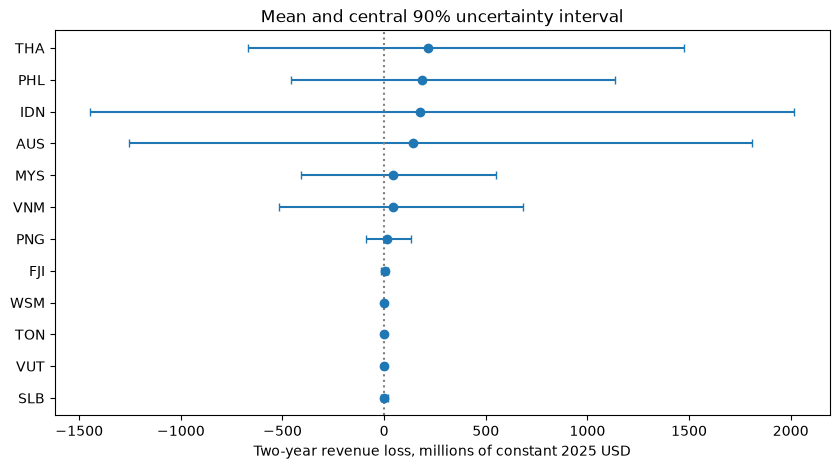

In [6]:
country = pd.read_csv(REPORT / 'event_country_risk.csv')
total = country[country.year.eq('2026–2027')].sort_values('revenue_loss_2025usd_mean')
fig, ax = plt.subplots(figsize=(10, 5))
mean = total.revenue_loss_2025usd_mean / 1e6
err = np.vstack([mean-total.revenue_loss_2025usd_p05/1e6, total.revenue_loss_2025usd_p95/1e6-mean])
ax.errorbar(mean, total.country, xerr=err, fmt='o', capsize=3)
ax.axvline(0, color='grey', linestyle=':')
ax.set(xlabel='Two-year revenue loss, millions of constant 2025 USD', title='Mean and central 90% uncertainty interval')
plt.show()

## 4. Commodity-specific interpretation

The crop model separates yield, harvested area and supported local USD producer-price responses. Crop effects overlap the aggregate value-added channel and must not be added to fiscal results. Tonnage equivalents use observed production scale, not a claim about future planting or absolute output.

In [7]:
crops = pd.read_csv(REPORT / 'event_crop_impacts.csv')
crops.loc[crops.year.eq(2027), ['country','crop','yield_effect_pct_mean','yield_effect_pct_p05','yield_effect_pct_p95','p_yield_loss','price_response_estimated']].sort_values('yield_effect_pct_mean').head(20)

,country,crop,yield_effect_pct_mean,yield_effect_pct_p05,yield_effect_pct_p95,p_yield_loss,price_response_estimated
87,PHL,coconut,-7.448738,-14.651124,-1.041723,0.9712,True
123,WSM,coconut,-6.636347,-13.516565,-0.298725,0.9560,False
111,TON,coconut,-6.625673,-13.552876,-0.236918,0.9553,False
80,MYS,coconut,-6.277728,-12.471869,-0.369185,0.9589,True
84,MYS,rice,-6.049672,-11.401608,-1.617339,0.9908,False
67,FJI,coconut,-5.856214,-12.537792,0.514819,0.9374,False
91,PHL,rice,-5.710283,-10.715355,-1.269278,0.9847,True
105,THA,coconut,-5.633125,-11.910066,0.172533,0.9441,True
70,FJI,rice,-5.423980,-11.708885,0.264429,0.9424,True
101,SLB,coconut,-5.351945,-11.843160,0.873215,0.9229,False


## 5. Does the model predict well?

Convergence and predictive skill are separate. Rolling benchmark comparisons and Bayesian post-2018 holdouts are conditional on realized historical inputs and use revised data. They do not reproduce forecasts actually available at the time. Scores that fail to improve on simpler baselines remain in the report. Short-history countries missing from a holdout model are not counted as validated.

In [8]:
pd.read_csv(REPORT / 'macro_validation.csv')

,kind,model,n,rmse,crps,coverage90,validation_type
0,agriculture,baseline,180,0.056137,0.028123,0.872222,conditional final-vintage rolling hindcast; ri...
1,agriculture,with_climate,180,0.058756,0.031469,0.738889,conditional final-vintage rolling hindcast; ri...
2,fiscal,baseline,180,0.090579,0.048747,0.827778,conditional final-vintage rolling hindcast; ri...
3,fiscal,with_agriculture,180,0.093558,0.050640,0.811111,conditional final-vintage rolling hindcast; ri...


In [9]:
pd.DataFrame([json.loads((REPORT / f'{kind}_bayesian_validation.json').read_text()) for kind in ['agriculture','fiscal']])

,kind,training_end,n,rmse,crps,coverage90,type
0,agriculture,2018,60,0.060001,0.029389,0.933333,Bayesian conditional holdout with realized inp...
1,fiscal,2018,66,0.082443,0.045716,0.939394,Bayesian conditional holdout with realized inp...


## 6. Structural uncertainty and extrapolation

Late-2027 climate evolution, dependence, onset and fiscal priors change the answer. Alternatives are separate assumptions, not probability-weighted consensus forecasts. Extreme combinations with few historical analogues remain uncertain even when MCMC converges.

In [10]:
sensitivity = pd.read_csv(REPORT / 'event_sensitivity.csv')
sensitivity[sensitivity.scope.eq('excluding_Australia') & sensitivity.period.eq('2026–2027')][['variant','revenue_loss_2025usd_mean','revenue_loss_2025usd_p05','revenue_loss_2025usd_p95','p_revenue_loss','es95_2025usd']]

,variant,revenue_loss_2025usd_mean,revenue_loss_2025usd_p05,revenue_loss_2025usd_p95,p_revenue_loss,es95_2025usd
8,neutral_late_2027,6.695230e+08,-2.178764e+09,4.291702e+09,0.6352,6.135025e+09
17,la_nina_late_2027,6.573168e+08,-2.162172e+09,4.270816e+09,0.6332,6.070914e+09
26,independent_forecast_errors,7.276807e+08,-2.336950e+09,4.537638e+09,0.6374,6.233912e+09
35,aligned_forecast_errors,6.680216e+08,-2.214470e+09,4.306131e+09,0.6335,6.244563e+09
44,independent_economic_shocks,6.772856e+08,-2.177895e+09,4.359264e+09,0.6323,6.203150e+09
53,onset_june,6.638693e+08,-2.171959e+09,4.310784e+09,0.6315,6.123402e+09
62,zero_direct_fiscal_transmission,-4.777467e+07,-1.171674e+08,1.265814e+07,0.0896,3.372493e+07
71,central,6.774783e+08,-2.211986e+09,4.372169e+09,0.6329,6.207708e+09
80,fiscal_prior_scale_0.5,1.984825e+08,-1.445160e+09,2.118115e+09,0.5696,3.026087e+09
89,fiscal_prior_scale_4.0,9.107339e+08,-2.362607e+09,5.264718e+09,0.6555,7.742304e+09


In [11]:
pd.read_csv(REPORT / 'event_extrapolation.csv')

,year,feature,training_min,training_max,forecast_mean,probability_outside_training_range,neutral_mean
0,2026,warm,0.0,1.275000,1.211036,0.3139,0.000000
1,2026,warm_lag1,0.0,1.275000,0.000000,0.0000,0.000000
2,2026,warm_lag2,0.0,1.275000,0.191667,0.0000,0.191667
3,2026,cold,0.0,1.200000,0.175000,0.0000,0.175000
4,2026,extreme,0.0,0.266667,0.345279,0.7210,0.000000
5,2026,cold_lag1,0.0,1.200000,0.725000,0.0000,0.725000
6,2026,cold_lag2,0.0,1.200000,0.433333,0.0000,0.433333
7,2027,warm,0.0,1.275000,0.648906,0.0252,0.000000
8,2027,warm_lag1,0.0,1.275000,1.211036,0.3139,0.000000
9,2027,warm_lag2,0.0,1.275000,0.000000,0.0000,0.000000


## 7. What the study does not establish

The fiscal channel excludes event-driven inflation/FX feedback, non-agricultural spillovers, emergency spending and policy adaptation. Annual fiscal/calendar alignment and crop timing are approximate. Historical country weather is not crop-weighted live weather. Parameter covariance between the two separately fitted macro models is not estimated. Full structural and measurement uncertainty is not exhausted by posterior intervals.

Institutional comparison is scoped in `docs/EVENT_SOURCES.md`: JRC and the World Bank support relevant channels and broader economic context, while IMF supplies macro references. No matching institutional 2026–2027 sovereign-revenue distribution independently validates these estimates.

Each refresh archives provider responses, verifies source vintages, refits changed training data and publishes only a complete successful run. New climate forecasts update risk immediately; annual data and their publication lags are respected.